# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 07: AUDIO CNN MODEL USING FMA-LARGE AS SOURCE
# ============================================================
# Purpose:
# This notebook uses the FMA-Large audio archive as the source
# for unstructured modelling. It does NOT require downloading
# fma_small or fma_medium separately.
#
# Instead, tracks.csv is used to:
# 1. Identify tracks with usable top-level labels (genre_top)
# 2. Preserve the official train/validation/test split
# 3. Build a controlled pilot audio subset from the large archive
# 4. Convert audio into Mel spectrograms
# 5. Train a CNN for genre classification
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================
# This helps reduce run-to-run variation in CNN results.

import random
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional: stronger determinism
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic ops enabled.")
except Exception as e:
    print("Deterministic ops not enabled:", e)

print("Seeds set to:", SEED)

TensorFlow deterministic ops enabled.
Seeds set to: 42


In [3]:
# ============================================================
# 2. LOAD TRACK METADATA
# ============================================================

tracks = pd.read_csv(
    "../data/raw/metadata/tracks.csv",
    header=[0, 1],
    index_col=0
)

print("Tracks shape:", tracks.shape)

Tracks shape: (106574, 52)


In [4]:
# ============================================================
# 3. FILTER TO THE LARGE SUBSET
# ============================================================
# We use rows tagged as belonging to the large subset.
# Then we keep only rows where genre_top exists so that the task
# remains a single-label top-level genre classification problem.

tracks_large = tracks[tracks[("set", "subset")] == "large"].copy()

print("Large subset raw shape:", tracks_large.shape)

tracks_large = tracks_large[tracks_large[("track", "genre_top")].notna()].copy()

print("Large subset with genre_top:", tracks_large.shape)

Large subset raw shape: (81574, 52)
Large subset with genre_top: (24598, 52)


In [5]:
# ============================================================
# 4. DEFINE AUDIO ROOT FOR FMA-LARGE
# ============================================================
# This folder should contain subfolders such as 000, 001, 002, etc.

audio_base_path = "../data/raw/audio/fma_large"

In [6]:
# ============================================================
# 5. FUNCTION TO BUILD AUDIO PATHS
# ============================================================

def get_audio_path(track_id, audio_root=audio_base_path):
    track_id_str = f"{int(track_id):06d}"
    folder = track_id_str[:3]
    return os.path.join(audio_root, folder, track_id_str + ".mp3")


In [7]:
# ============================================================
# 6. ATTACH AUDIO PATHS AND CHECK WHICH FILES EXIST
# ============================================================

tracks_large["audio_path"] = [get_audio_path(track_id) for track_id in tracks_large.index]
tracks_large["audio_exists"] = tracks_large["audio_path"].apply(os.path.exists)

print("Audio existence check:")
print(tracks_large["audio_exists"].value_counts())

tracks_large = tracks_large[tracks_large["audio_exists"] == True].copy()

print("Large subset with labels and audio present:", tracks_large.shape)


Audio existence check:
audio_exists
True    24598
Name: count, dtype: int64
Large subset with labels and audio present: (24598, 54)


In [8]:
# ============================================================
# 7. INSPECT AVAILABLE TOP-LEVEL GENRES
# ============================================================
# We now examine the genres that have both labels and audio files.

genre_counts = tracks_large[("track", "genre_top")].value_counts()

print("Genre counts with labels and audio:")
print(genre_counts)

Genre counts with labels and audio:
(track, genre_top)
Experimental           8357
Rock                   7079
Electronic             3058
Hip-Hop                1351
Folk                   1284
Pop                    1146
Instrumental            729
Classical               611
International           371
Spoken                  305
Jazz                    187
Old-Time / Historic      44
Blues                    36
Soul-RnB                 21
Country                  16
Easy Listening            3
Name: count, dtype: int64


In [9]:
# ============================================================
# 8. SELECT A PILOT SET OF GENRES
# ============================================================
# For the first audio CNN, we do not use all possible classes.
# We select the most frequent top-level genres so that:
# - each class has enough examples
# - the CNN can train stably
# - we still stay fully inside the FMA-Large archive
#
# top_n_genres can be increased later.

top_n_genres = 8
selected_genres = genre_counts.head(top_n_genres).index.tolist()

print("Selected top genres:")
print(selected_genres)

tracks_audio = tracks_large[
    tracks_large[("track", "genre_top")].isin(selected_genres)
].copy()

print("Filtered audio modelling frame:", tracks_audio.shape)

Selected top genres:
['Experimental', 'Rock', 'Electronic', 'Hip-Hop', 'Folk', 'Pop', 'Instrumental', 'Classical']
Filtered audio modelling frame: (23615, 54)


In [10]:
# ============================================================
# 9. BUILD A BALANCED PILOT SUBSET BY SPLIT
# ============================================================
# We preserve the official split, but cap the number of examples
# per genre within each split so that the first CNN run remains
# manageable and balanced.
#
# You can increase these values later after the pipeline works.

train_cap = 250
val_cap = 50
test_cap = 50

def sample_by_genre_and_split(df, split_name, cap):
    split_df = df[df[("set", "split")] == split_name].copy()
    parts = []
    for genre in selected_genres:
        genre_df = split_df[split_df[("track", "genre_top")] == genre]
        if len(genre_df) > 0:
            parts.append(genre_df.sample(n=min(cap, len(genre_df)), random_state=42))
    if len(parts) == 0:
        return pd.DataFrame()
    return pd.concat(parts).sort_index()

train_df = sample_by_genre_and_split(tracks_audio, "training", train_cap)
val_df = sample_by_genre_and_split(tracks_audio, "validation", val_cap)
test_df = sample_by_genre_and_split(tracks_audio, "test", test_cap)

pilot_df = pd.concat([train_df, val_df, test_df]).sort_index()

print("Pilot train shape:", train_df.shape)
print("Pilot validation shape:", val_df.shape)
print("Pilot test shape:", test_df.shape)
print("Pilot total shape:", pilot_df.shape)

print("\nPilot class distribution:")
print(pilot_df[("track", "genre_top")].value_counts())

Pilot train shape: (2000, 54)
Pilot validation shape: (362, 54)
Pilot test shape: (375, 54)
Pilot total shape: (2737, 54)

Pilot class distribution:
(track, genre_top)
Rock            350
Folk            350
Experimental    350
Hip-Hop         350
Electronic      350
Pop             350
Instrumental    350
Classical       287
Name: count, dtype: int64


In [11]:
# ============================================================
# 10A. FUNCTION TO EXTRACT MEL SPECTROGRAM
# ============================================================
# We load each MP3 and transform it into a Mel spectrogram.
# A Mel spectrogram is an image-like time-frequency representation
# of sound and is commonly used for audio CNNs.
#
# We also force a fixed width so every input has the same shape.

def extract_mel_spectrogram(file_path, sr=22050, duration=30, n_mels=128, target_width=1292):
    try:
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)

        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sample_rate,
            n_mels=n_mels
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        if mel_spec_db.shape[1] < target_width:
            pad_width = target_width - mel_spec_db.shape[1]
            mel_spec_db = np.pad(
                mel_spec_db,
                ((0, 0), (0, pad_width)),
                mode="constant"
            )
        else:
            mel_spec_db = mel_spec_db[:, :target_width]

        return mel_spec_db

    except Exception as e:
        print("Error processing:", file_path, e)
        return None

In [12]:
# ============================================================
# 10B. CREATE A CLEAN AUDIO WORKING DATAFRAME
# ============================================================
# pilot_df contains MultiIndex columns from tracks.csv.
# To avoid issues when iterating row by row, we create a clean
# plain dataframe with only the fields needed for audio modelling.

pilot_audio_df = pd.DataFrame({
    "track_id": pilot_df.index.astype(int),
    "genre_top": pilot_df[("track", "genre_top")].astype(str).values,
    "split": pilot_df[("set", "split")].astype(str).values
}, index=pilot_df.index)

# Rebuild audio paths from track_id
pilot_audio_df["audio_path"] = pilot_audio_df["track_id"].apply(get_audio_path)

# Confirm the files exist
pilot_audio_df["audio_exists"] = pilot_audio_df["audio_path"].apply(os.path.exists)

print("Pilot audio existence check:")
print(pilot_audio_df["audio_exists"].value_counts())

pilot_audio_df = pilot_audio_df[pilot_audio_df["audio_exists"] == True].copy()

print("Clean pilot audio dataframe shape:", pilot_audio_df.shape)
pilot_audio_df.head()

Pilot audio existence check:
audio_exists
True    2737
Name: count, dtype: int64
Clean pilot audio dataframe shape: (2737, 5)


,track_id,genre_top,split,audio_path,audio_exists
track_id,,,,,
171,171,Rock,training,../data/raw/audio/fma_large\000\000171.mp3,True
178,178,Rock,training,../data/raw/audio/fma_large\000\000178.mp3,True
189,189,Folk,training,../data/raw/audio/fma_large\000\000189.mp3,True
191,191,Folk,training,../data/raw/audio/fma_large\000\000191.mp3,True
205,205,Folk,training,../data/raw/audio/fma_large\000\000205.mp3,True


In [13]:
# ============================================================
# 11. EXTRACT SPECTROGRAMS FOR THE PILOT SUBSET
# ============================================================
# We now iterate over the clean dataframe where audio_path is a
# normal string column.

X_audio = []
y_audio = []
split_audio = []
track_ids_audio = []

for _, row in tqdm(pilot_audio_df.iterrows(), total=len(pilot_audio_df)):
    file_path = row["audio_path"]
    genre = row["genre_top"]
    split_name = row["split"]
    track_id = row["track_id"]

    spec = extract_mel_spectrogram(file_path)

    if spec is not None:
        X_audio.append(spec)
        y_audio.append(genre)
        split_audio.append(split_name)
        track_ids_audio.append(track_id)

X_audio = np.array(X_audio)
y_audio = np.array(y_audio)
split_audio = np.array(split_audio)
track_ids_audio = np.array(track_ids_audio)

print("X_audio shape:", X_audio.shape)
print("y_audio shape:", y_audio.shape)
print("split_audio shape:", split_audio.shape)

if len(X_audio) == 0:
    raise ValueError("No spectrograms were extracted. Check audio paths and extraction.")

100%|██████████| 2737/2737 [04:10<00:00, 10.93it/s]


X_audio shape: (2737, 128, 1292)
y_audio shape: (2737,)
split_audio shape: (2737,)


In [14]:
# ============================================================
# 12. RESHAPE FOR CNN INPUT
# ============================================================

X_audio = X_audio[..., np.newaxis]

print("CNN input shape:", X_audio.shape)

CNN input shape: (2737, 128, 1292, 1)


In [15]:
# ============================================================
# 13. ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_audio)

print("Encoded classes:")
print(label_encoder.classes_)

Encoded classes:
['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [16]:
# ============================================================
# 14. CREATE TRAIN / VALIDATION / TEST ARRAYS
# ============================================================

X_train = X_audio[split_audio == "training"]
y_train = y_encoded[split_audio == "training"]

X_val = X_audio[split_audio == "validation"]
y_val = y_encoded[split_audio == "validation"]

X_test = X_audio[split_audio == "test"]
y_test = y_encoded[split_audio == "test"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("One of the train/validation/test splits is empty.")

Train: (2000, 128, 1292, 1) (2000,)
Validation: (362, 128, 1292, 1) (362,)
Test: (375, 128, 1292, 1) (375,)


In [17]:
# ============================================================
# 15. NORMALIZE INPUTS
# ============================================================

def safe_normalize(X):
    if X.size == 0:
        return X
    denom = np.max(np.abs(X))
    if denom == 0:
        return X
    return X / denom

X_train = safe_normalize(X_train)
X_val = safe_normalize(X_val)
X_test = safe_normalize(X_test)

print("Normalization complete.")

Normalization complete.


In [18]:
# ============================================================
# 16. BUILD CNN MODEL
# ============================================================

num_classes = len(label_encoder.classes_)

cnn_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 1290, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 645, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 643, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 321, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 319, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 159, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 142464)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,235,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,259,848 (69.66 MB)

 Trainable params: 18,259,848 (69.66 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# 17. TRAIN THE CNN
# ============================================================
# EarlyStopping helps prevent unnecessary training if the model
# stops improving on validation loss.

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.1529 - loss: 2.5959 - val_accuracy: 0.1602 - val_loss: 2.0402
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.2015 - loss: 1.9795 - val_accuracy: 0.1657 - val_loss: 2.0606
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step - accuracy: 0.2190 - loss: 1.9522 - val_accuracy: 0.1685 - val_loss: 2.0811
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step - accuracy: 0.2686 - loss: 1.8704 - val_accuracy: 0.1989 - val_loss: 2.0844


In [20]:
# ============================================================
# 18. TEST EVALUATION
# ============================================================

test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)

print("CNN Test Accuracy:", test_accuracy)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.1664 - loss: 2.0846
CNN Test Accuracy: 0.13333334028720856


In [21]:
# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

y_pred_probs = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
              precision    recall  f1-score   support

   Classical       0.00      0.00      0.00        25
  Electronic       0.60      0.06      0.11        50
Experimental       0.00      0.00      0.00        50
        Folk       0.00      0.00      0.00        50
     Hip-Hop       0.00      0.00      0.00        50
Instrumental       0.50      0.04      0.07        50
         Pop       0.19      0.06      0.09        50
        Rock       0.12      0.84      0.21        50

    accuracy                           0.13       375
   macro avg       0.18      0.12      0.06       375
weighted avg       0.19      0.13      0.06       375



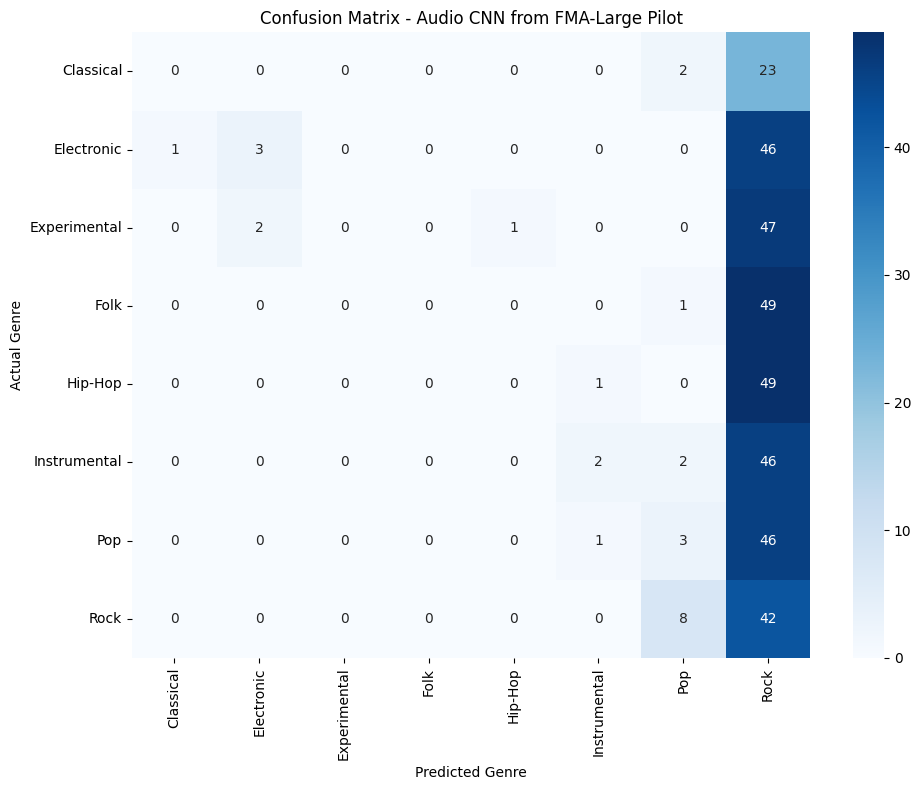

In [22]:
# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Audio CNN from FMA-Large Pilot")
plt.tight_layout()
plt.show()

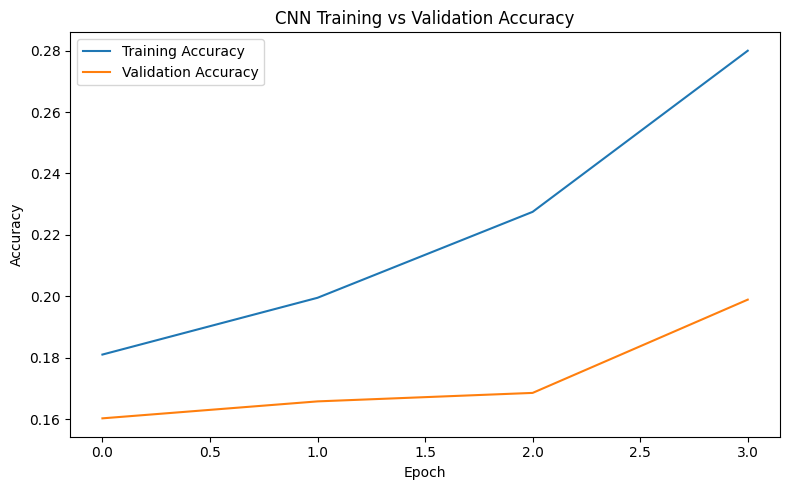

In [23]:
# ============================================================
# 21. PLOT TRAINING HISTORY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# ============================================================
# 22. SAVE A METADATA SNAPSHOT OF THE PILOT SET
# ============================================================
# This is useful for reproducibility and documentation.

pilot_metadata_export = pilot_df.copy()
pilot_metadata_export["encoded_label"] = label_encoder.transform(
    pilot_df[("track", "genre_top")]
)

pilot_metadata_export.to_csv("../data/processed/audio_large_pilot_metadata.csv")

print("Saved pilot metadata to ../data/processed/audio_large_pilot_metadata.csv")

Saved pilot metadata to ../data/processed/audio_large_pilot_metadata.csv


In [25]:
# ============================================================
# SAVE ARRAYS AND BASELINE RESULTS FOR NOTEBOOK 08
# ============================================================

import os
os.makedirs("../data/processed", exist_ok=True)

# Save dataset arrays
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_val.npy", X_val)
np.save("../data/processed/X_test.npy", X_test)

np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/y_val.npy", y_val)
np.save("../data/processed/y_test.npy", y_test)

# Save class names
np.save("../data/processed/label_classes.npy", label_encoder.classes_)

# Save baseline CNN accuracy
with open("../data/processed/baseline_audio_test_accuracy.txt", "w") as f:
    f.write(str(test_accuracy))

print("Saved arrays, classes, and baseline accuracy for Notebook 08.")

Saved arrays, classes, and baseline accuracy for Notebook 08.
